# Final training project

In [1]:
from neural_networks.Recurrent import FusionNN
import torch
import numpy as np

np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = FusionNN(neurons = 256, hidden_size=12000)
model.load_state_dict(torch.load("models/nn/FusionNN.pt"))
model.to(device)

/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory
/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


FusionNN(
  (encoders): ModuleList(
    (0): CNN2D(
      (conv): Sequential(
        (0): Conv2d(13, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): LeakyReLU(negative_slope=0.01)
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): LeakyReLU(negative_slope=0.01)
        (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (5): LeakyReLU(negative_slope=0.01)
        (6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (7): LeakyReLU(negative_slope=0.01)
        (8): AdaptiveAvgPool2d(output_size=(2, 2))
      )
      (shared_fc): Sequential(
        (0): Linear(in_features=1024, out_features=256, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=256, out_features=256, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=256, out_features=256, bias=True)
        (5): LeakyReLU(negative_slope=0.01)
  

In [2]:
from sklearn.preprocessing import StandardScaler
from dataLoader import *

scaler = StandardScaler()

msi = load_images(MSI_SATELLITE_TRAIN_DIR)
hsi = load_images(HSI_SATELLITE_DIR)
airborne = load_images(HSI_AIRBORNE_DIR)
y = gt_train_df[column_names].values
y = scaler.fit_transform(y)
y_binned = np.digitize(y, bins=np.linspace(y.min(), y.max() + 1, 5))
y = torch.tensor(y, dtype=torch.float32)

In [3]:
from torch.utils.data import Dataset, DataLoader

class MultiSourceDataset(Dataset):
    def __init__(self, msi, hsi, airborne, targets):
        self.msi = msi
        self.hsi = hsi
        self.airborne = airborne
        self.targets = targets

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (
            self.msi[idx],
            self.hsi[idx],
            self.airborne[idx],
            self.targets[idx]
        )
        
dataset = MultiSourceDataset(msi, hsi, airborne, y)
dataloader = DataLoader(dataset, batch_size=len(dataset))

## Global SHAP

In [4]:
import torch.nn as nn

class FusionEmbedding(nn.Module):
    def __init__(self, fusion_model):
        super().__init__()
        self.encoders = fusion_model.encoders
        self.fc = fusion_model.fc

    def forward(self, msi, hsi):
        msi_feat = self.encoders[0].extract_features(msi)
        hsi_feat = self.encoders[1].extract_features(hsi)

        fused = torch.cat([msi_feat, hsi_feat], dim=1)

        return self.fc(fused)

wrapped = FusionEmbedding(model).to(device)

In [5]:
np.random.seed(42)
background_idx = np.random.choice(
    len(dataset),
    size=100,
    replace=False
)
msi = torch.stack(msi)
hsi = torch.stack(hsi)
background_msi = msi[background_idx].to(device)
background_hsi = hsi[background_idx].to(device)

In [6]:
msi_test = []
hsi_test = []

for msi, his, _, _ in dataloader:
    msi_test.append(msi)
    hsi_test.append(hsi)

msi_test = torch.cat(msi_test)[:200].to(device)
hsi_test = torch.cat(hsi_test)[:200].to(device)

In [7]:
from shap import DeepExplainer

explainer = DeepExplainer( wrapped, [background_msi, background_hsi])

shap_values = explainer.shap_values(
    [msi_test, hsi_test])

msi_importance = 0
hsi_importance = 0

for output in shap_values:
    msi_importance += np.abs(output[0].sum())
    hsi_importance += np.abs(output[1].sum())

total = msi_importance + hsi_importance

print(f"MSI: {100 * msi_importance / total:.2f}%")
print(f"HSI: {100 * hsi_importance / total:.2f}%")

MSI: 41.42%
HSI: 58.58%


In [8]:
hsi_importance

np.float64(2.560671549199838)

msi_importance = np.float64(1.8107590760449788)

hsi_importance = np.float64(2.560671540847498)

MSI: 44.01%

HSI: 55.99%

## HSI

In [9]:
from neural_networks.Convolutional import CNN2D
model_hsi = CNN2D(channels = 231, neurons = 256, out_channels=6)
model_hsi.load_state_dict(torch.load("models/nn/CNN2D_HSI.pt"))
model_hsi.to(device)
model_hsi.eval()

hsi_explainer = DeepExplainer(
    model_hsi,
    background_hsi
)
shap_values = hsi_explainer.shap_values(hsi_test)

print(type(shap_values))

if isinstance(shap_values, list):
    print("number of outputs:", len(shap_values))
    print("shape:", shap_values[0].shape)
else:
    print("shape:", shap_values.shape)

<class 'numpy.ndarray'>
shape: (200, 231, 7, 7, 6)


Fe


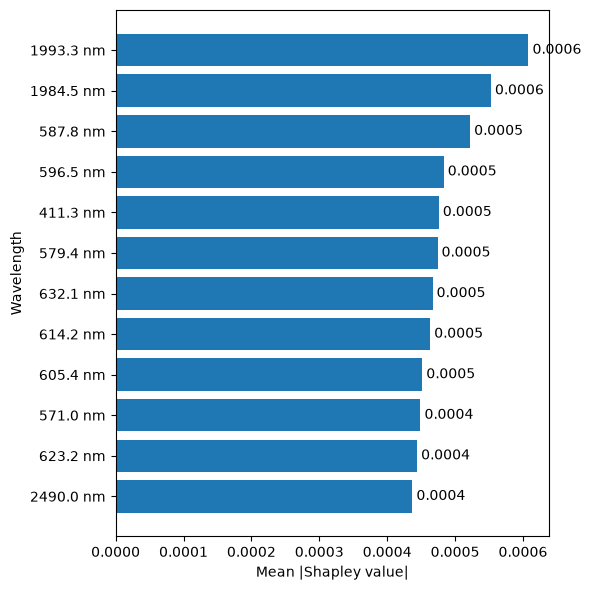

Zn


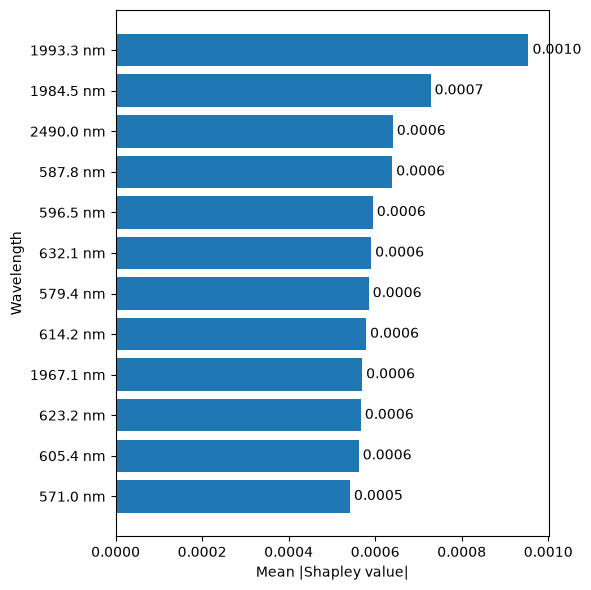

B


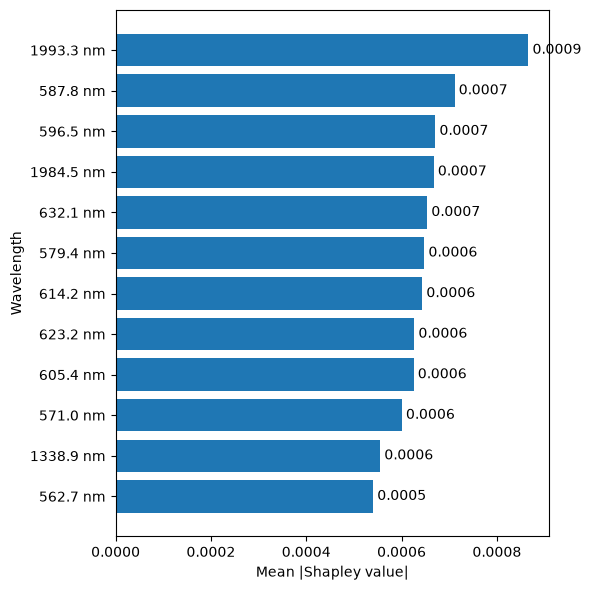

Cu


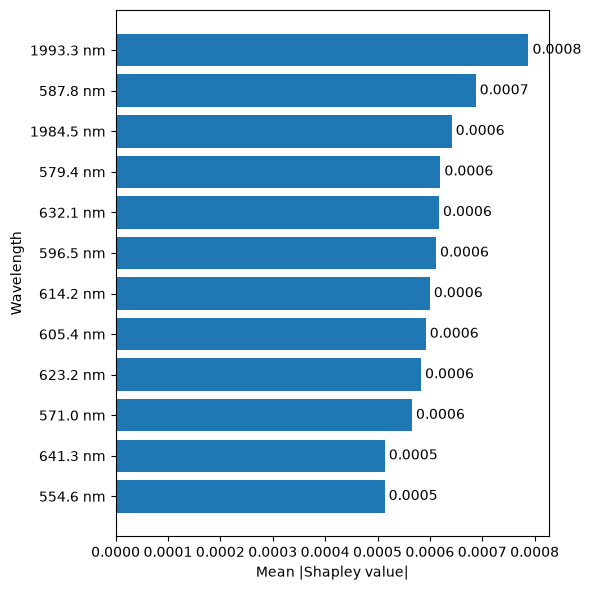

S


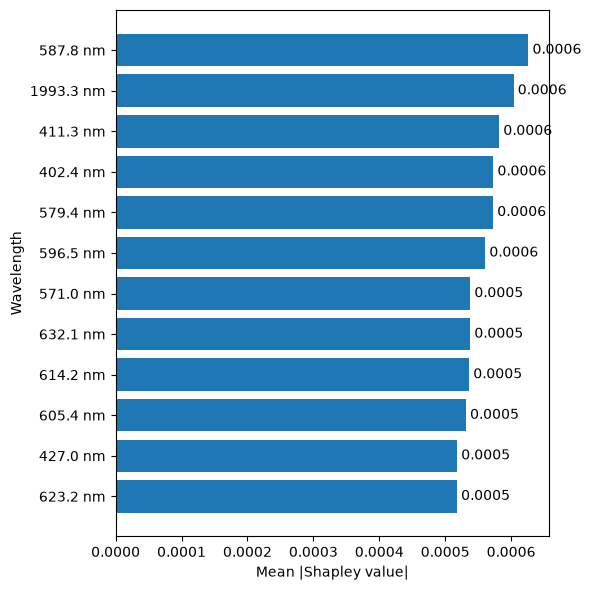

Mn


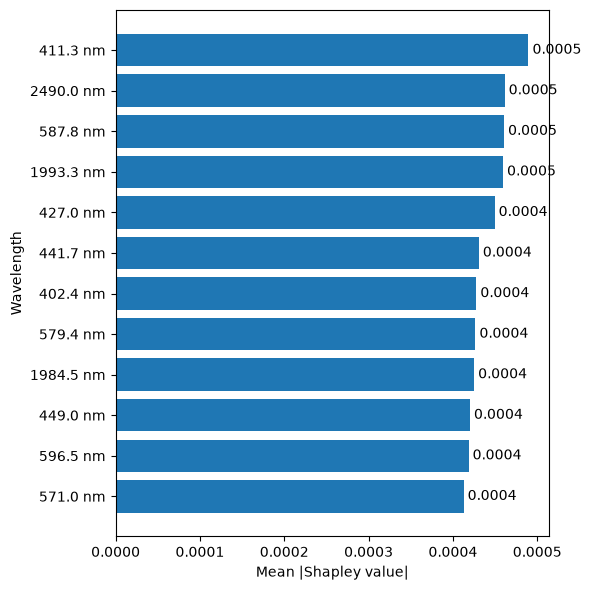

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("wavelengths.json", "r") as f:
    wavelengths_data = json.load(f)

wavelengths_dict = wavelengths_data["hsi_satellite_wavelengths"]

wavelengths = np.array([
    wavelengths_dict[f"Band {i}"]
    for i in range(230)
])

channel_importance = np.abs(shap_values).mean(axis=(0, 2, 3))
channel_importance = channel_importance[:-1]

for output in range(6):
    importance = channel_importance[:, output]
    top12 = np.argsort(importance)[-12:][::-1]
    values = importance[top12]
    top12 = top12[::-1]
    values = values[::-1]
    labels = [
        f"{wavelengths[channel]:.1f} nm"
        for channel in top12
    ]

    plt.figure(figsize=(6, 6))
    bars = plt.barh(
        labels,
        values
    )
    plt.xlabel("Mean |Shapley value|")
    plt.ylabel("Wavelength")
    print(column_names[output])
    for bar, value in zip(bars, values):
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {value:.4f}",
            va="center"
        )
    plt.tight_layout()
    plt.savefig(f"hsi_{column_names[output]}.pdf")
    plt.show()

## MSI

In [11]:
from neural_networks.Convolutional import CNN2D
model_msi = CNN2D(channels = 13, neurons = 256, out_channels=6)
model_msi.load_state_dict(torch.load("models/nn/CNN2D_MSI.pt"))
model_msi.to(device)
model_msi.eval()

msi_explainer = DeepExplainer(
    model_msi,
    background_msi
)
shap_values = msi_explainer.shap_values(msi_test)

print(type(shap_values))

if isinstance(shap_values, list):
    print("number of outputs:", len(shap_values))
    print("shape:", shap_values[0].shape)
else:
    print("shape:", shap_values.shape)

<class 'numpy.ndarray'>
shape: (200, 13, 7, 7, 6)


Fe


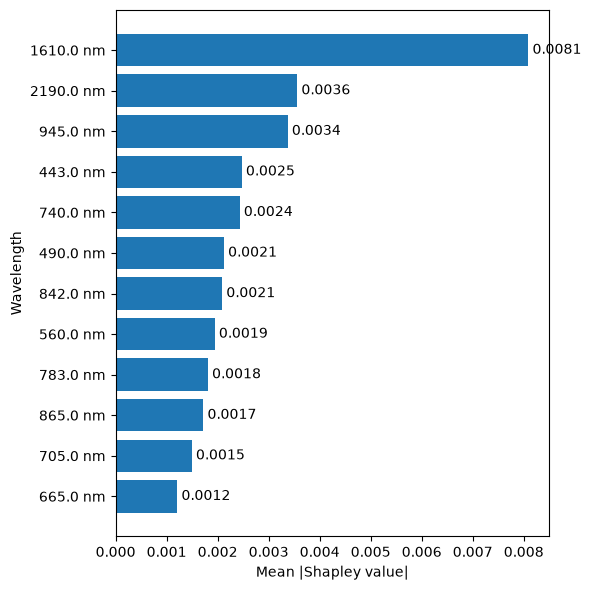

Zn


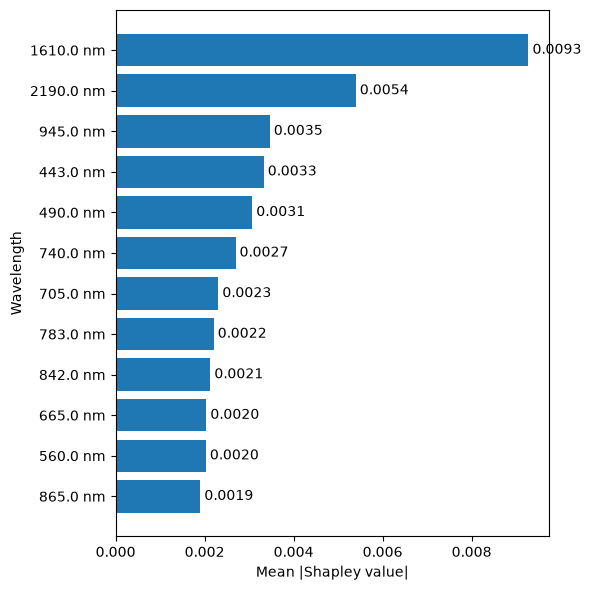

B


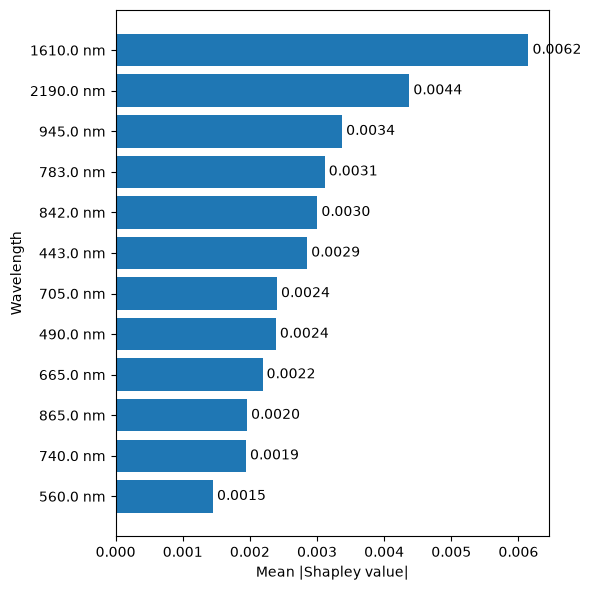

Cu


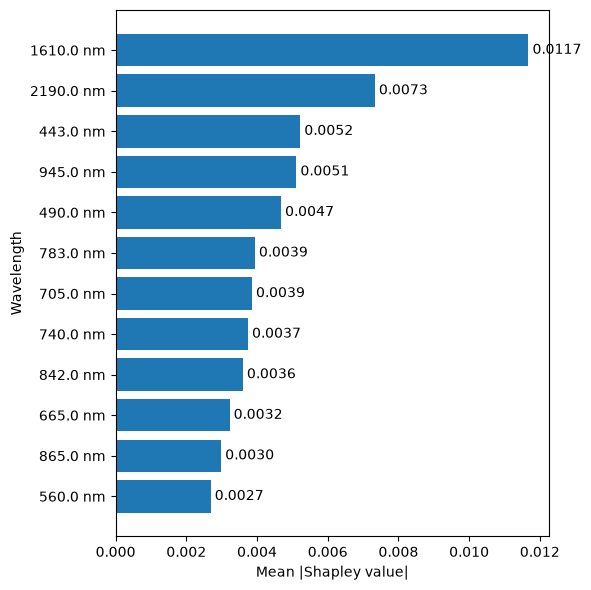

S


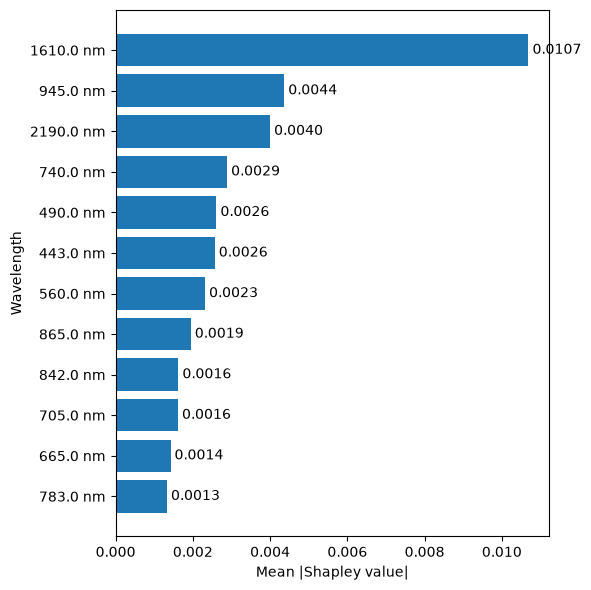

Mn


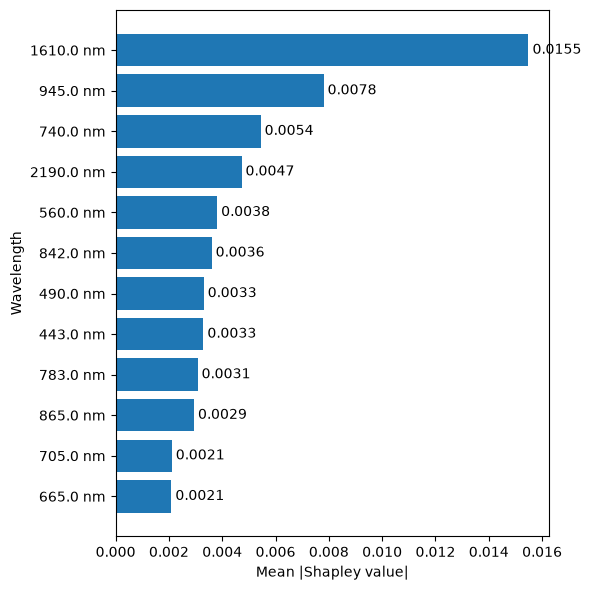

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("wavelengths.json", "r") as f:
    wavelengths_data = json.load(f)

wavelengths_dict = wavelengths_data["msi_satellite_wavelengths"]

wavelengths = np.array([
    value for _, value in wavelengths_dict.items()
])

channel_importance = np.abs(shap_values).mean(axis=(0, 2, 3))
channel_importance = channel_importance[:-1]

for output in range(6):
    importance = channel_importance[:, output]
    top12 = np.argsort(importance)[-12:][::-1]
    values = importance[top12]
    top12 = top12[::-1]
    values = values[::-1]
    labels = [
        f"{wavelengths[channel]:.1f} nm"
        for channel in top12
    ]

    plt.figure(figsize=(6, 6))
    bars = plt.barh(
        labels,
        values
    )
    plt.xlabel("Mean |Shapley value|")
    plt.ylabel("Wavelength")
    print(column_names[output])
    for bar, value in zip(bars, values):
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {value:.4f}",
            va="center"
        )
    plt.tight_layout()
    plt.savefig(f"msi_{column_names[output]}.pdf")
    plt.show()

## SLIC and LIME for HSI

In [13]:
from lime import lime_image
from skimage.segmentation import slic

In [14]:
def predict_cnn(images, model, output_idx):
    x = torch.tensor(
        images,
        dtype=torch.float32,
        device=device
    )

    x = x.permute(0, 3, 1, 2)
    model.eval()
    with torch.no_grad():
        output = model(x)

    output = output[:, output_idx]
    return output.cpu().numpy().reshape(-1, 1)

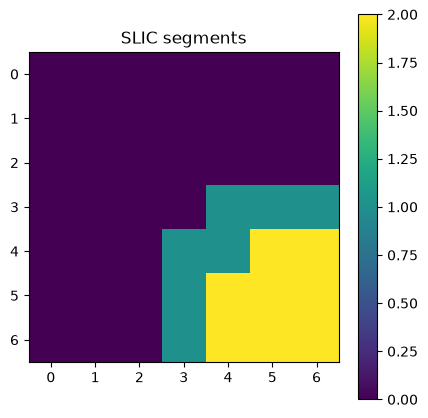

In [15]:
image_hwc = hsi[0].permute(1, 2, 0).numpy()
segments = slic(
    image_hwc,
    n_segments=4,
    compactness=0.1,
    channel_axis=-1,
    start_label=0
)

plt.figure(figsize=(5, 5))
plt.imshow(segments)
plt.colorbar()
plt.title("SLIC segments")
plt.show()

In [24]:
np.random.seed(42)
sample_idx = np.random.choice(
    len(hsi),
    size=1500,
    replace=False,
)

hsi_explain = hsi[sample_idx]
msi_explain = msi[sample_idx]

In [25]:
import numpy as np
import torch
from skimage.segmentation import slic
from sklearn.linear_model import Ridge

def lime_superpixel_frequency(
    model,
    data,
    output_idx,
    device,
    n_samples=500,
    n_segments=8,
    top_k=3,
):

    model.eval()
    H = data.shape[2]
    W = data.shape[3]

    frequency_map = np.zeros((H, W), dtype=np.float32)
    for sample_idx in range(len(data)):
        image = data[sample_idx].cpu().numpy()
        C, H, W = image.shape
        image_hwc = np.transpose(image, (1, 2, 0))
        segments = slic(
            image_hwc,
            n_segments=n_segments,
            compactness=0.1,
            start_label=0,
            channel_axis=-1
        )
        segment_ids = np.unique(segments)
        n_seg = len(segment_ids)
        perturbations = np.random.randint(
            0, 2,
            size=(n_samples, n_seg)
        )
        perturbations[0] = 1
        mean_spectrum = image.mean(axis=(1, 2))
        perturbed = np.empty(
            (n_samples, C, H, W),
            dtype=np.float32
        )

        for i in range(n_samples):

            img = image.copy()

            for j, seg in enumerate(segment_ids):
                if perturbations[i, j] == 0:
                    mask = segments == seg
                    img[:, mask] = mean_spectrum[:, None]
            perturbed[i] = img
        x = torch.tensor(
            perturbed,
            dtype=torch.float32,
            device=device
        )
        with torch.no_grad():
            y = model(x)[:, output_idx].cpu().numpy()
            
        distances = np.sum(
            perturbations == 0,
            axis=1
        )

        sigma = np.sqrt(n_seg) * 0.75
        weights = np.exp(
            -(distances ** 2) /
            (sigma ** 2)
        )
        reg = Ridge(alpha=1.0)
        reg.fit(
            perturbations,
            y,
            sample_weight=weights
        )
        coef = np.abs(reg.coef_)
        important_segments = np.argsort(coef)[-top_k:]
        for seg_idx in important_segments:
            frequency_map[
                segments == segment_ids[seg_idx]
            ] += 1

    frequency_map /= len(data)
    return frequency_map

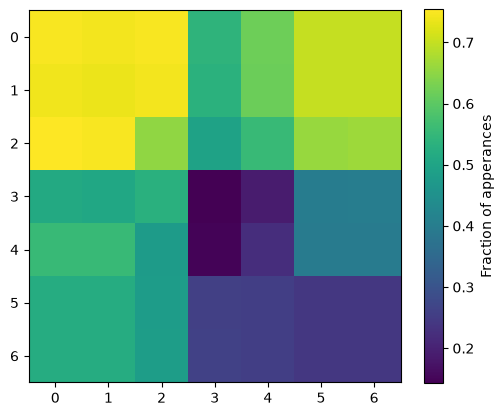

In [27]:
frequency = lime_superpixel_frequency(
    model=model_hsi,
    data=hsi,
    output_idx=0,
    device=device,
    n_samples=len(hsi),
    n_segments=8,
    top_k=4
)

plt.figure(figsize=(6,6))
plt.imshow(frequency)
plt.colorbar(label="Fraction of apperances", shrink=0.81)
plt.savefig("lime_hsi.pdf")
plt.show()

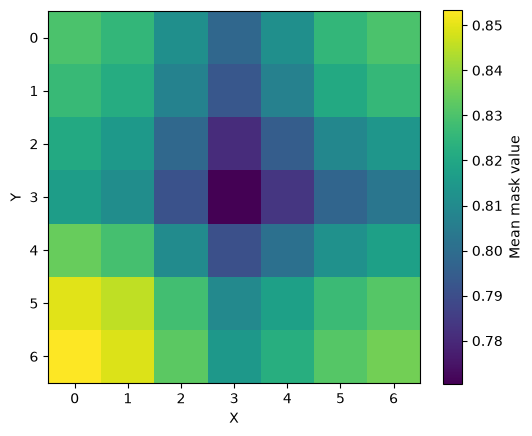

In [28]:
masks = hsi[:, -1, :, :].cpu().numpy()
mean_mask = masks.mean(axis=0)
plt.figure(figsize=(6, 6))

plt.imshow(mean_mask)

plt.colorbar(label="Mean mask value", shrink=0.81)
plt.xlabel("X")
plt.ylabel("Y")
plt.savefig("mean_mask_hsi.pdf")
plt.show()

## SLIC with LIME for MSI

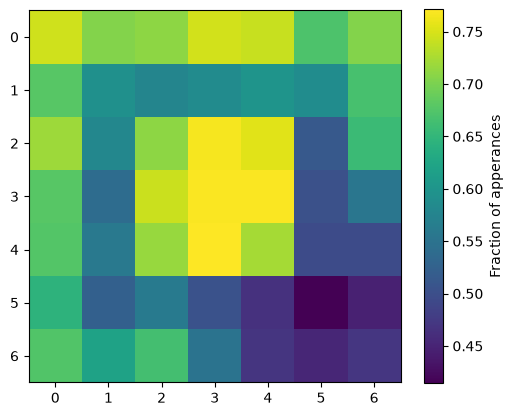

In [31]:
frequency = lime_superpixel_frequency(
    model=model_msi,
    data=msi,
    output_idx=0,
    device=device,
    n_samples=len(msi),
    n_segments=8,
    top_k=4
)

plt.figure(figsize=(6,6))
plt.imshow(frequency)
plt.colorbar(label="Fraction of apperances", shrink=0.81)
plt.savefig("lime_msi.pdf")
plt.show()

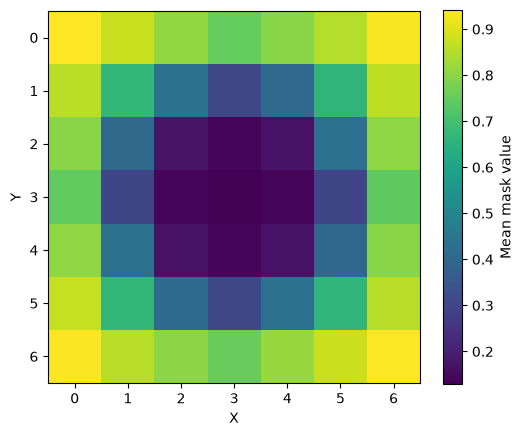

In [33]:
masks = msi[:, -1, :, :].cpu().numpy()
mean_mask = masks.mean(axis=0)
plt.figure(figsize=(6, 6))

plt.imshow(mean_mask)

plt.colorbar(label="Mean mask value", shrink=0.81)

plt.xlabel("X")
plt.ylabel("Y")
plt.savefig("mean_mask_msi.pdf")
plt.show()

# EBM

In [ ]:
from MultiOutputTuner import MultiOutputTuner
from interpret import show

msi_ebm = load_msi_data(MSI_SATELLITE_TRAIN_DIR)
ebm = MultiOutputTuner.load("models/hsi/ebm")

with open("wavelengths.json", "r") as f:
    wavelengths = json.load(f)

feature_names = [
    f"{wavelength:.1f} nm"
    for wavelength in wavelengths["msi_satellite_wavelengths"].values()
]

print(feature_names)
for i, pipeline in enumerate(ebm.models):
    model = pipeline.named_steps["model"]
    model.feature_names = feature_names
    explanation = model.explain_global()
    print(column_names[i])
    show(explanation)

In [ ]:
model = ebm.models[0].named_steps["model"]

print(type(model))
print(model.feature_names)
print(model.get_params())

In [ ]:
pipeline = ebm.models[0]
model = pipeline.named_steps["model"]

explanation = model.explain_global()

data = explanation.data()

print(data.keys())
print(data["names"])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

with open("wavelengths.json", "r") as f:
    wavelengths = json.load(f)

feature_names = [
    f"{x:.1f} nm"
    for x in wavelengths["msi_satellite_wavelengths"].values()
]

for i, pipeline in enumerate(ebm.models):

    model = pipeline.named_steps["model"]

    explanation = model.explain_global()
    data = explanation.data()

    # Pierwsze 12 elementów = główne efekty cech
    scores = np.array(data["scores"][:len(feature_names)])

    # Top 13, albo wszystkie jeśli masz 12 kanałów
    top_n = min(13, len(scores))

    top = np.argsort(scores)[-top_n:][::-1]

    values = scores[top]
    labels = [feature_names[j] for j in top]

    # Największy na górze
    values = values[::-1]
    labels = labels[::-1]

    plt.figure(figsize=(6, 6))

    bars = plt.barh(labels, values)

    plt.xlabel("EBM global importance")
    plt.ylabel("Wavelength")

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {value:.4f}",
            va="center"
        )

    plt.tight_layout()
    plt.savefig(f"ebm_{column_names[i]}.pdf")
    plt.show()